# Predicting Electrolyte Transport Properties from Concentration Fields
## 4-Channel CNN with Two-Phase Training

**Phase 1:** Joint training on all samples — learns D-sensitive backbone features.

**Phase 2:** Freeze backbone + D head, retrain t⁺⁰ head with per-sample steadiness weighting.


## 0. Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
import copy
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from scipy.special import comb
import glob, os, pandas as pd

torch.manual_seed(42)
np.random.seed(42)


In [2]:
# Configuration
DATA_PATH = '/Users/ZirongHe/Desktop/C242 Machine Learning/Final project/fixed_rho_data_4ch.pt'
N_OUTPUTS, N_D, N_TP, N_CHANNELS = 8, 4, 4, 4
BATCH_SIZE, WEIGHT_DECAY = 64, 1e-4
VAL_FRACTION, TEST_FRACTION = 0.15, 0.15

# Phase 1
EPOCHS_P1, LR_P1, BOUNDARY_WEIGHT_P1, PATIENCE_P1 = 50, 1e-4, 0.2, 10

# Phase 2
EPOCHS_P2, LR_P2, BOUNDARY_WEIGHT_P2, PATIENCE_P2 = 50, 5e-4, 0.2, 15


<details>
<summary><b>Dataset class (click to expand)</b></summary>
Parses COMSOL CSV files. 4 channels: c(x,t), t, ∂c/∂x, ∂c/∂t. Required for unpickling the saved .pt file.
</details>


In [3]:
class MultiFileSpatioTemporalDataset_4ch(Dataset):
    def __init__(self, folder_path, C_max=6000.0):
        file_list = sorted(glob.glob(os.path.join(folder_path, "batch_*_conc.csv")))
        if not file_list: raise ValueError(f"No CSV files found in {folder_path}")
        with open(file_list[0], 'r') as f:
            skip_idx = 0
            for i, line in enumerate(f):
                if line.startswith('% X,t'): skip_idx = i; break
        sample_df = pd.read_csv(file_list[0], sep=',', skiprows=skip_idx)
        sample_df.rename(columns={sample_df.columns[0]: 'x'}, inplace=True)
        if sample_df['x'].dtype == object:
            sample_df['x'] = sample_df['x'].astype(str).str.replace('% ', '').astype(float)
        x_unique, t_unique = np.sort(sample_df['x'].unique()), np.sort(sample_df['t'].unique())
        self.N_x, self.N_t = len(x_unique), len(t_unique)
        self.x, self.t = torch.tensor(x_unique, dtype=torch.float32), torch.tensor(t_unique, dtype=torch.float32)
        self.dx, self.dt, self.C_max = np.diff(x_unique), np.diff(t_unique), C_max
        t_arr = t_unique.astype(np.float64)
        t_linear = (t_arr - t_arr.min()) / (t_arr.max() - t_arr.min() + 1e-12)
        self._time_channel = np.tile(t_linear, (self.N_x, 1)).astype(np.float32)
        all_c, all_dcdx, all_dcdt, all_targets = [], [], [], []
        for file in file_list:
            with open(file, 'r') as f:
                for i, line in enumerate(f):
                    if line.startswith('% X,t'): skip_idx = i; break
            df = pd.read_csv(file, sep=',', skiprows=skip_idx)
            c_cols = [col for col in df.columns if col.startswith('c (mol/m^3) @')]
            c_raw = df[c_cols].values.T.reshape(-1, self.N_x, self.N_t)
            for c in c_raw:
                c_norm = (c / C_max).astype(np.float32)
                dcdx = np.diff(c_norm, axis=0) / self.dx[:, None].astype(np.float32)
                dcdx = np.concatenate([dcdx, dcdx[-1:, :]], axis=0)
                am = np.abs(dcdx).max()
                if am > 1e-10: dcdx = dcdx / am
                dcdt = np.diff(c_norm, axis=1) / self.dt[None, :].astype(np.float32)
                dcdt = np.concatenate([dcdt, dcdt[:, -1:]], axis=1)
                am = np.abs(dcdt).max()
                if am > 1e-10: dcdt = dcdt / am
                all_c.append(c_norm); all_dcdx.append(dcdx.astype(np.float32)); all_dcdt.append(dcdt.astype(np.float32))
            for col in c_cols: all_targets.append(self._parse_targets(col))
            del df
        self.c_grids, self.dcdx, self.dcdt = np.array(all_c), np.array(all_dcdx), np.array(all_dcdt)
        self.Total_S = len(all_c)
        self.targets = {
            'rho': np.array([t['rho'] for t in all_targets], dtype=np.float32),
            'Tf': np.array([t['Tf'] for t in all_targets], dtype=np.float32),
            'D': np.array([t['D'] for t in all_targets], dtype=np.float32),
            'kappa': np.array([t['kappa'] for t in all_targets], dtype=np.float32),
            't_param': np.array([t['t'] for t in all_targets], dtype=np.float32),
        }
    def _parse_targets(self, header_string):
        param_chunk = header_string.split('@')[1].strip()
        parsed = {'rho': [], 'Tf': [], 'D': [], 'kappa': [], 't': []}
        for pair in param_chunk.split(';'):
            if '=' in pair:
                k, v = pair.split('='); base = k.strip().split('_')[0]
                if base in parsed: parsed[base].append(float(v.strip()))
        return parsed
    def __len__(self): return self.Total_S
    def __getitem__(self, idx):
        inp = torch.tensor(np.stack([self.c_grids[idx], self._time_channel, self.dcdx[idx], self.dcdt[idx]]), dtype=torch.float32)
        return inp, {k: torch.tensor(v[idx]) for k, v in self.targets.items()}


## 1. Load Data & Preprocess


In [ ]:
if torch.cuda.is_available(): device = torch.device("cuda")
elif torch.backends.mps.is_available(): device = torch.device("mps")
else: device = torch.device("cpu")
print(f"Device: {device}")

dataset = torch.load(DATA_PATH, map_location='cpu', weights_only=False)
N_samples = dataset.Total_S

X = np.stack([np.stack([dataset.c_grids[i], dataset._time_channel, dataset.dcdx[i], dataset.dcdt[i]])
              for i in range(N_samples)]).astype(np.float32)
y = np.concatenate([dataset.targets['D'], dataset.targets['t_param']], axis=1).astype(np.float32)
print(f"Samples: {N_samples}, X: {X.shape}, y: {y.shape}")


## 2. Steadiness Weights
Samples closer to steady state get higher weight during Phase 2 t⁺⁰ training.
Weight = inverse of late-time ∂c/∂t RMS, normalized to [0, 1].


In [5]:
N_t = dataset.c_grids.shape[2]
late_start = int(N_t * 0.9)

late_dcdt_rms = np.zeros(N_samples)
for i in range(N_samples):
    late_c = dataset.c_grids[i][:, late_start:]
    if late_c.shape[1] > 1:
        late_dcdt_rms[i] = np.sqrt((np.diff(late_c, axis=1) ** 2).mean())

epsilon = np.percentile(late_dcdt_rms, 5)
raw_weight = 1.0 / (late_dcdt_rms + epsilon)
steadiness_weight = (raw_weight - raw_weight.min()) / (raw_weight.max() - raw_weight.min())
print(f"Steadiness weights: min={steadiness_weight.min():.4f}, median={np.median(steadiness_weight):.4f}, max={steadiness_weight.max():.4f}")


Steadiness weights: min=0.0000, median=0.0967, max=1.0000


## 3. Train/Val/Test Split


In [6]:
indices = np.arange(N_samples)
idx_trainval, idx_test = train_test_split(indices, test_size=TEST_FRACTION, random_state=42)
idx_train, idx_val = train_test_split(idx_trainval, test_size=VAL_FRACTION/(1-TEST_FRACTION), random_state=42)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
w_train, w_val, w_test = steadiness_weight[idx_train], steadiness_weight[idx_val], steadiness_weight[idx_test]

y_mean, y_std = y_train.mean(axis=0), y_train.std(axis=0) + 1e-8
y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 1400, Val: 300, Test: 300


## 4. Model
Two-head CNN: shared backbone (4 conv blocks → 256-dim), separate D and t⁺⁰ MLP heads.


In [7]:
class CNN_TwoHead(nn.Module):
    def __init__(self, in_channels=4, n_D=4, n_tp=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, padding=2), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.D_head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
                                    nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, n_D))
        self.tp_head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
                                     nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, n_tp))
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear): nn.init.kaiming_normal_(m.weight, nonlinearity='relu'); nn.init.zeros_(m.bias)
    def forward(self, x):
        feat = self.features(x)
        return torch.cat([self.D_head(feat), self.tp_head(feat)], dim=1)

model = CNN_TwoHead(in_channels=N_CHANNELS)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 474,536


<details>
<summary><b>Training functions (click to expand)</b></summary>
<code>train_phase1</code>: joint training with boundary-weighted MSE loss.
<code>train_phase2</code>: t⁺⁰ head only, per-sample steadiness weighting, backbone frozen.
</details>


In [8]:
def weighted_mse_loss(pred, target, coeff_weights):
    return ((pred - target) ** 2 * coeff_weights).mean()

def train_phase1(model, X_train, y_train, X_val, y_val,
                 epochs=50, lr=1e-4, batch_size=64, weight_decay=1e-4,
                 patience=10, device='cpu', boundary_weight=0.2):
    model = model.to(device)
    w = boundary_weight
    loss_weights = torch.tensor([w,1,1,w, w,1,1,w], dtype=torch.float32, device=device)
    loss_weights = loss_weights * (len(loss_weights) / loss_weights.sum())
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=batch_size)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_val, best_w, pat = float('inf'), None, 0
    for epoch in range(epochs):
        model.train(); t_loss = 0
        for X_b, y_b in tqdm(train_loader, desc=f"P1 Ep {epoch+1}", leave=False):
            X_b, y_b = X_b.to(device), y_b.to(device); optimizer.zero_grad()
            loss = weighted_mse_loss(model(X_b), y_b, loss_weights); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step(); t_loss += loss.item()
        t_loss /= len(train_loader)
        model.eval(); all_p, all_t = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device); p = model(X_b)
                all_p.append(p.cpu()); all_t.append(y_b.cpu())
        v_loss = weighted_mse_loss(torch.cat(all_p), torch.cat(all_t), loss_weights.cpu()).item()
        mse = ((torch.cat(all_p) - torch.cat(all_t))**2).mean(dim=0).numpy()
        scheduler.step(v_loss)
        if v_loss < best_val: best_val, best_w, pat = v_loss, copy.deepcopy(model.state_dict()), 0
        else: pat += 1
        print(f"P1 Ep {epoch+1:3d} | train:{t_loss:.4f} val:{v_loss:.4f} | D:[{mse[0]:.3f},{mse[1]:.3f},{mse[2]:.3f},{mse[3]:.3f}] t⁺⁰:[{mse[4]:.3f},{mse[5]:.3f},{mse[6]:.3f},{mse[7]:.3f}]")
        if pat >= patience: print(f"Early stopping at epoch {epoch+1}"); break
    if best_w: model.load_state_dict(best_w)
    return model

def train_phase2(model, X_train, y_train, w_train, X_val, y_val, w_val,
                 epochs=80, lr=5e-4, batch_size=64, weight_decay=1e-4,
                 patience=15, device='cpu', boundary_weight=0.2):
    model = model.to(device)
    for p in model.features.parameters(): p.requires_grad = False
    for p in model.D_head.parameters(): p.requires_grad = False
    model.features.eval()
    w_bnd = boundary_weight
    tp_cw = torch.tensor([w_bnd,1,1,w_bnd], dtype=torch.float32, device=device)
    tp_cw = tp_cw * (len(tp_cw) / tp_cw.sum())
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train), torch.tensor(w_train, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val), torch.tensor(w_val, dtype=torch.float32)), batch_size=batch_size)
    optimizer = torch.optim.AdamW([p for p in model.tp_head.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_val, best_w, pat = float('inf'), None, 0
    print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params (tp_head only)")
    for epoch in range(epochs):
        model.tp_head.train(); model.features.eval(); model.D_head.eval(); t_loss = 0
        for X_b, y_b, w_b in tqdm(train_loader, desc=f"P2 Ep {epoch+1}", leave=False):
            X_b, y_b, w_b = X_b.to(device), y_b.to(device), w_b.to(device); optimizer.zero_grad()
            pred = model(X_b); sq = (pred[:,N_D:] - y_b[:,N_D:])**2
            loss = (((sq * tp_cw).mean(dim=1)) * w_b).mean()
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.tp_head.parameters(), 1.0); optimizer.step(); t_loss += loss.item()
        t_loss /= len(train_loader)
        model.eval(); all_p, all_t = [], []
        with torch.no_grad():
            for X_b, y_b, w_b in val_loader:
                all_p.append(model(X_b.to(device)).cpu()); all_t.append(y_b)
        mse = ((torch.cat(all_p) - torch.cat(all_t))**2).mean(dim=0).numpy()
        val_tp = mse[N_D:].mean(); scheduler.step(val_tp)
        if val_tp < best_val: best_val, best_w, pat = val_tp, copy.deepcopy(model.state_dict()), 0
        else: pat += 1
        print(f"P2 Ep {epoch+1:3d} | tp_loss:{t_loss:.4f} | D:[{mse[0]:.3f},{mse[1]:.3f},{mse[2]:.3f},{mse[3]:.3f}] (frozen) | t⁺⁰:[{mse[4]:.3f},{mse[5]:.3f},{mse[6]:.3f},{mse[7]:.3f}]")
        if pat >= patience: print(f"Early stopping at epoch {epoch+1}"); break
    if best_w: model.load_state_dict(best_w)
    return model


## 5. Phase 1: Joint Training


In [ ]:
model = train_phase1(model, X_train, y_train_norm, X_val, y_val_norm,
                     epochs=EPOCHS_P1, lr=LR_P1, batch_size=BATCH_SIZE,
                     weight_decay=WEIGHT_DECAY, patience=PATIENCE_P1, device=device,
                     boundary_weight=BOUNDARY_WEIGHT_P1)
torch.save(model.state_dict(), 'phase1_4ch.pt')


## 6. Phase 2: t⁺⁰ Head (Steadiness-Weighted)


In [ ]:
model = train_phase2(model, X_train, y_train_norm, w_train, X_val, y_val_norm, w_val,
                     epochs=EPOCHS_P2, lr=LR_P2, batch_size=BATCH_SIZE,
                     weight_decay=WEIGHT_DECAY, patience=PATIENCE_P2, device=device,
                     boundary_weight=BOUNDARY_WEIGHT_P2)
torch.save(model.state_dict(), 'phase2_4ch_steady_weighted.pt')


## 7. Test Results


In [11]:
model.eval(); model = model.to(device)
all_preds, all_targets = [], []
with torch.no_grad():
    for i in range(0, len(X_test), BATCH_SIZE):
        X_b = torch.tensor(X_test[i:i+BATCH_SIZE]).to(device)
        all_preds.append(model(X_b).cpu().numpy())
        all_targets.append(y_test_norm[i:i+BATCH_SIZE])
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

def mse_r2(p, t):
    mse = ((p - t)**2).mean(axis=0)
    ss_res, ss_tot = ((p - t)**2).sum(axis=0), ((t - t.mean(axis=0))**2).sum(axis=0)
    return mse, 1 - ss_res / (ss_tot + 1e-8)

mse_D, r2_D = mse_r2(all_preds[:, :N_D], all_targets[:, :N_D])
mse_tp, r2_tp = mse_r2(all_preds[:, N_D:], all_targets[:, N_D:])

print("=" * 50)
print(f"{'Target':<12} {'MSE':<10} {'R²':<10}")
print("-" * 32)
for i in range(N_D):  print(f"D_{i:<10} {mse_D[i]:<10.4f} {r2_D[i]:<10.4f}")
print("-" * 32)
for i in range(N_TP): print(f"t⁺⁰_{i:<8} {mse_tp[i]:<10.4f} {r2_tp[i]:<10.4f}")
print("-" * 32)
print(f"{'D mean':<12} {mse_D.mean():<10.4f} {r2_D.mean():<10.4f}")
print(f"{'t⁺⁰ mean':<12} {mse_tp.mean():<10.4f} {r2_tp.mean():<10.4f}")


Target       MSE        R²        
--------------------------------
D_0          0.5108     0.4876    
D_1          0.2415     0.7624    
D_2          0.2101     0.7615    
D_3          0.4986     0.4802    
--------------------------------
t⁺⁰_0        0.8446     0.2077    
t⁺⁰_1        0.4047     0.5837    
t⁺⁰_2        0.4211     0.5726    
t⁺⁰_3        0.8044     0.1976    
--------------------------------
D mean       0.3653     0.6229    
t⁺⁰ mean     0.6187     0.3904    


<details>
<summary><b>Utility functions (click to expand)</b></summary>
Bernstein polynomial evaluation for reconstructing D(c) and t⁺⁰(c) curves.
</details>


In [12]:
def bernstein_basis(n, k, t):
    return comb(n, k) * (t**k) * ((1-t)**(n-k))

def bernstein_poly(coeffs, t):
    n = len(coeffs) - 1
    return sum(c * bernstein_basis(n, k, t) for k, c in enumerate(coeffs))

y_pred_phys = all_preds * y_std + y_mean
y_test_phys = all_targets * y_std + y_mean
c_eval = np.linspace(0, 1, 100)
c_obs_mask = (c_eval >= 0.3) & (c_eval <= 0.7)


## 8. Best & Worst Predictions
Per-sample RMSE in the observable range [0.3, 0.7], showing the 3 best and 3 worst for both D and t⁺⁰.


=== D(c) ===
BEST #1 | Sample 1699/2000 | RMSE=0.0039
  True coeffs:  [0.2474 0.7689 0.868  0.3145]
  Pred coeffs:  [0.2778 0.7699 0.8115 0.4066]
BEST #2 | Sample 1623/2000 | RMSE=0.0047
  True coeffs:  [0.4307 0.6524 0.773  0.301 ]
  Pred coeffs:  [0.3097 0.7523 0.7373 0.2714]
BEST #3 | Sample 1966/2000 | RMSE=0.0062
  True coeffs:  [0.0531 0.6509 0.5605 0.2659]
  Pred coeffs:  [0.1631 0.5366 0.618  0.2702]
WORST #1 | Sample 654/2000 | RMSE=0.0837
  True coeffs:  [0.061  0.526  0.9565 0.5944]
  Pred coeffs:  [0.3269 0.7496 0.7482 0.3114]
WORST #2 | Sample 1789/2000 | RMSE=0.0874
  True coeffs:  [0.051  0.6305 0.8057 0.685 ]
  Pred coeffs:  [0.3728 0.7765 0.7165 0.2461]
WORST #3 | Sample 1080/2000 | RMSE=0.0904
  True coeffs:  [0.4842 0.994  0.9925 0.8158]
  Pred coeffs:  [0.4725 0.9019 0.9363 0.5791]


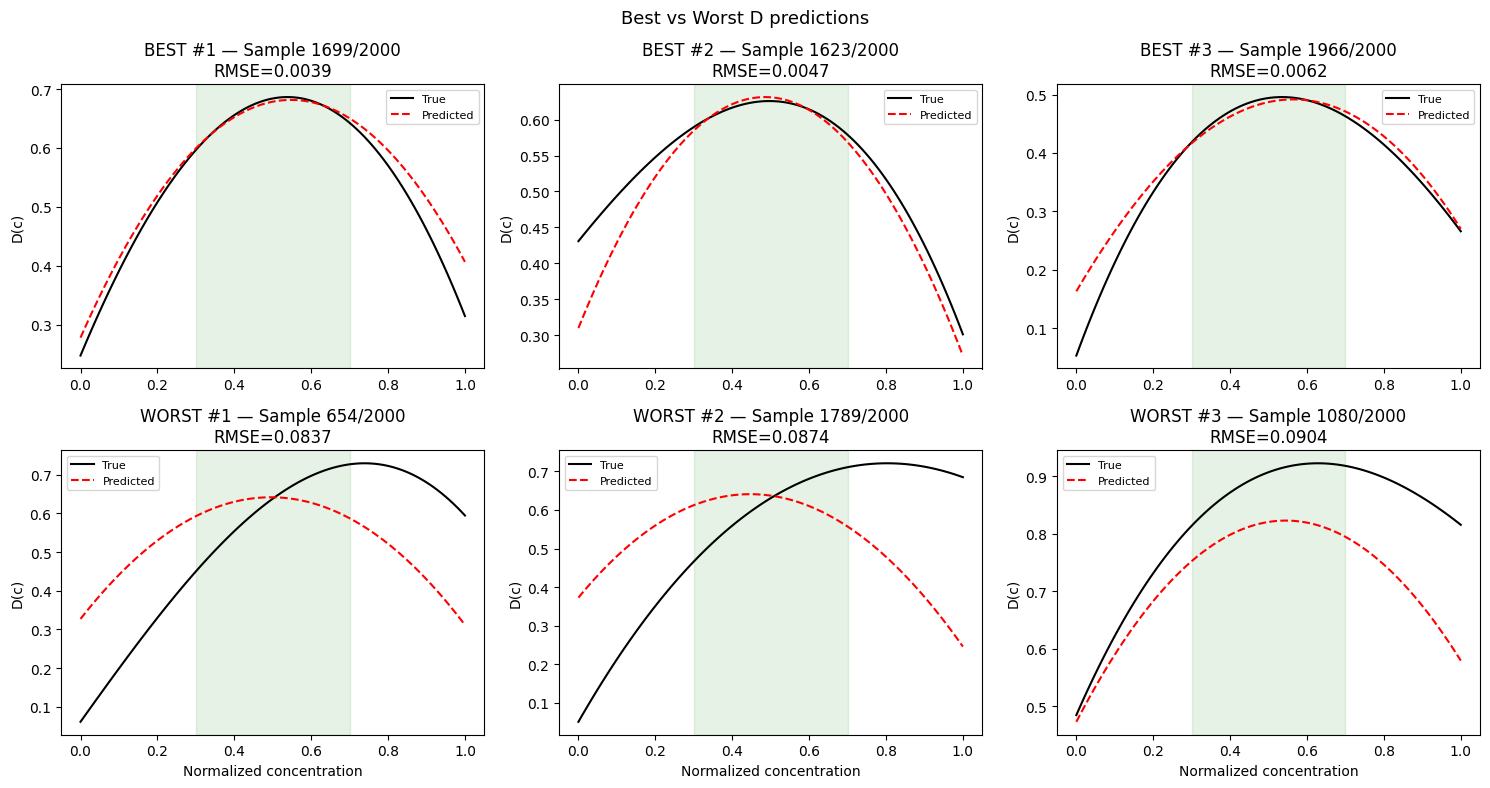


=== t⁺⁰(c) ===
BEST #1 | Sample 354/2000 | RMSE=0.0055
  True coeffs:  [0.1624 0.8918 0.1721 0.8758]
  Pred coeffs:  [0.5007 0.5273 0.5421 0.5259]
BEST #2 | Sample 1134/2000 | RMSE=0.0062
  True coeffs:  [0.0886 0.5156 0.1171 0.9492]
  Pred coeffs:  [0.326  0.198  0.4945 0.5518]
BEST #3 | Sample 307/2000 | RMSE=0.0064
  True coeffs:  [0.7374 0.227  0.7372 0.1298]
  Pred coeffs:  [0.5304 0.4939 0.4308 0.4592]
WORST #1 | Sample 1472/2000 | RMSE=0.0902
  True coeffs:  [0.9521 0.9291 0.0516 0.1683]
  Pred coeffs:  [0.6324 0.6854 0.3733 0.3491]
WORST #2 | Sample 964/2000 | RMSE=0.0922
  True coeffs:  [0.0713 0.3022 0.7863 0.7923]
  Pred coeffs:  [0.4793 0.4906 0.5606 0.549 ]
WORST #3 | Sample 1789/2000 | RMSE=0.1133
  True coeffs:  [0.9487 0.9669 0.0813 0.1925]
  Pred coeffs:  [0.5809 0.6115 0.4358 0.4445]


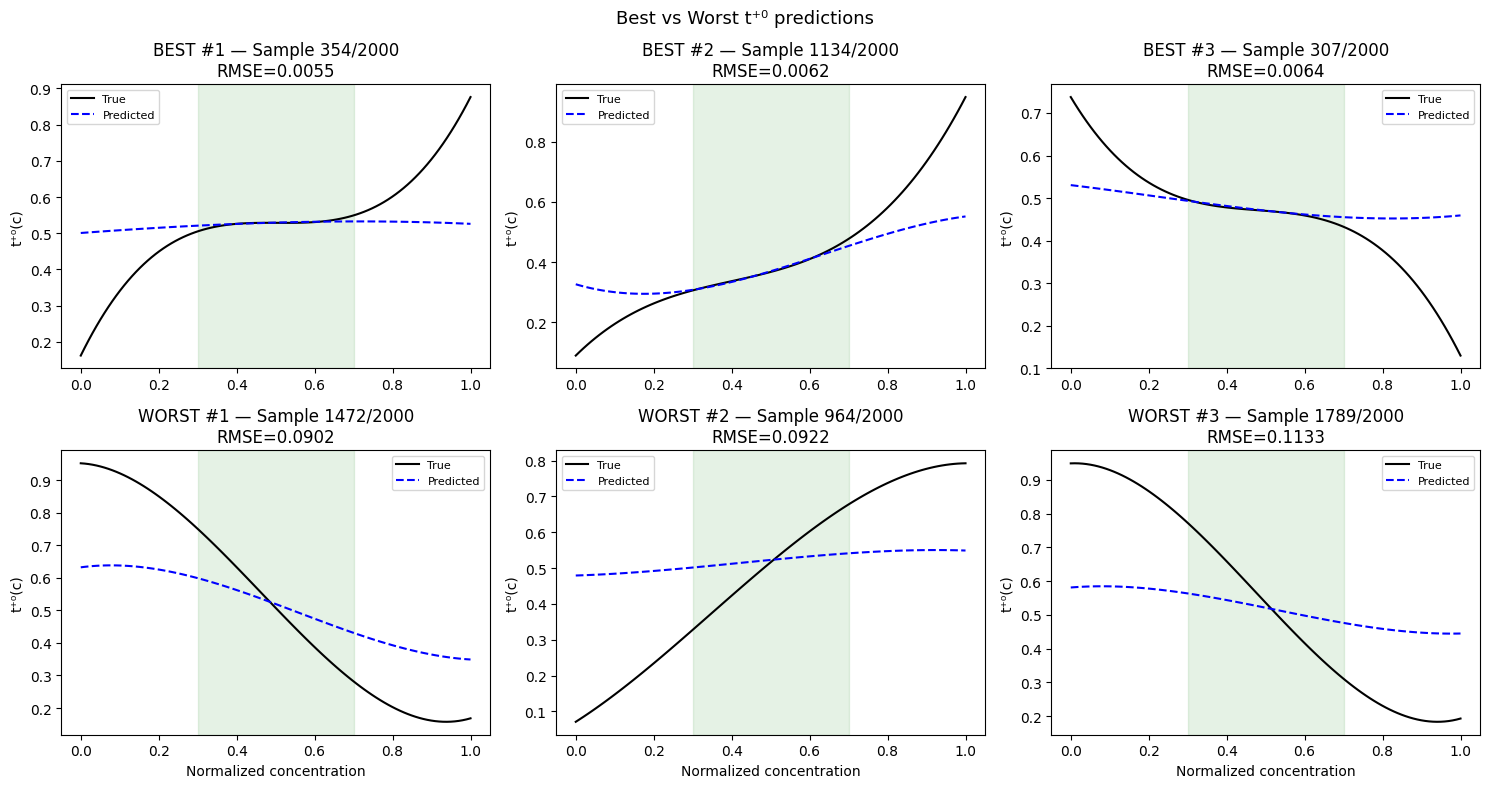

In [13]:
# Per-sample error in observable range
D_err_obs = np.zeros(len(y_test_phys))
tp_err_obs = np.zeros(len(y_test_phys))
for i in range(len(y_test_phys)):
    D_p = bernstein_poly(y_pred_phys[i, :4], c_eval)
    D_t = bernstein_poly(y_test_phys[i, :4], c_eval)
    D_err_obs[i] = np.sqrt(((D_p - D_t)**2)[c_obs_mask].mean())
    tp_p = bernstein_poly(y_pred_phys[i, 4:8], c_eval)
    tp_t = bernstein_poly(y_test_phys[i, 4:8], c_eval)
    tp_err_obs[i] = np.sqrt(((tp_p - tp_t)**2)[c_obs_mask].mean())

# Map test indices back to original dataset indices
test_dataset_ids = idx_test

def show_best_worst(err, prop_slice, prop_name, color):
    best_idx = np.argsort(err)[:3]
    worst_idx = np.argsort(err)[-3:]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for col, idx in enumerate(best_idx):
        dataset_id = test_dataset_ids[idx]
        pred_coeffs = y_pred_phys[idx, prop_slice]
        true_coeffs = y_test_phys[idx, prop_slice]
        curve_p = bernstein_poly(pred_coeffs, c_eval)
        curve_t = bernstein_poly(true_coeffs, c_eval)
        axes[0, col].plot(c_eval, curve_t, 'k-', label='True')
        axes[0, col].plot(c_eval, curve_p, color=color, ls='--', label='Predicted')
        axes[0, col].axvspan(0.3, 0.7, alpha=0.1, color='green')
        axes[0, col].set_title(f'BEST #{col+1} — Sample {dataset_id}/{N_samples}\nRMSE={err[idx]:.4f}')
        axes[0, col].set_ylabel(f'{prop_name}(c)')
        axes[0, col].legend(fontsize=8)
        print(f"BEST #{col+1} | Sample {dataset_id}/{N_samples} | RMSE={err[idx]:.4f}")
        print(f"  True coeffs:  {true_coeffs.round(4)}")
        print(f"  Pred coeffs:  {pred_coeffs.round(4)}")
    
    for col, idx in enumerate(worst_idx):
        dataset_id = test_dataset_ids[idx]
        pred_coeffs = y_pred_phys[idx, prop_slice]
        true_coeffs = y_test_phys[idx, prop_slice]
        curve_p = bernstein_poly(pred_coeffs, c_eval)
        curve_t = bernstein_poly(true_coeffs, c_eval)
        axes[1, col].plot(c_eval, curve_t, 'k-', label='True')
        axes[1, col].plot(c_eval, curve_p, color=color, ls='--', label='Predicted')
        axes[1, col].axvspan(0.3, 0.7, alpha=0.1, color='green')
        axes[1, col].set_title(f'WORST #{col+1} — Sample {dataset_id}/{N_samples}\nRMSE={err[idx]:.4f}')
        axes[1, col].set_ylabel(f'{prop_name}(c)')
        axes[1, col].set_xlabel('Normalized concentration')
        axes[1, col].legend(fontsize=8)
        print(f"WORST #{col+1} | Sample {dataset_id}/{N_samples} | RMSE={err[idx]:.4f}")
        print(f"  True coeffs:  {true_coeffs.round(4)}")
        print(f"  Pred coeffs:  {pred_coeffs.round(4)}")
    
    plt.suptitle(f'Best vs Worst {prop_name} predictions', fontsize=13)
    plt.tight_layout(); plt.show()

print("=== D(c) ===")
show_best_worst(D_err_obs, slice(0, 4), 'D', 'red')
print("\n=== t⁺⁰(c) ===")
show_best_worst(tp_err_obs, slice(4, 8), 't⁺⁰', 'blue')


In [21]:
# Save y mean and y std
np.save('/Users/ZirongHe/Desktop/C242 Machine Learning/Final project/y_mean.npy', y_mean)
np.save('/Users/ZirongHe/Desktop/C242 Machine Learning/Final project/y_std.npy', y_std)

=== Best D samples — corresponding t⁺⁰ ===
  #1 Sample 1699/2000 | D RMSE=0.0039 | t⁺⁰ RMSE=0.0127
    t⁺⁰ true: [0.7164 0.0567 0.4115 0.4585]
    t⁺⁰ pred: [0.4243 0.2784 0.2931 0.4322]
  #2 Sample 1623/2000 | D RMSE=0.0047 | t⁺⁰ RMSE=0.0242
    t⁺⁰ true: [0.7432 0.2441 0.0046 0.8281]
    t⁺⁰ pred: [0.4446 0.2576 0.2542 0.3833]
  #3 Sample 1966/2000 | D RMSE=0.0062 | t⁺⁰ RMSE=0.0634
    t⁺⁰ true: [0.1171 0.1204 0.2523 0.038 ]
    t⁺⁰ pred: [0.3364 0.1746 0.1584 0.3449]


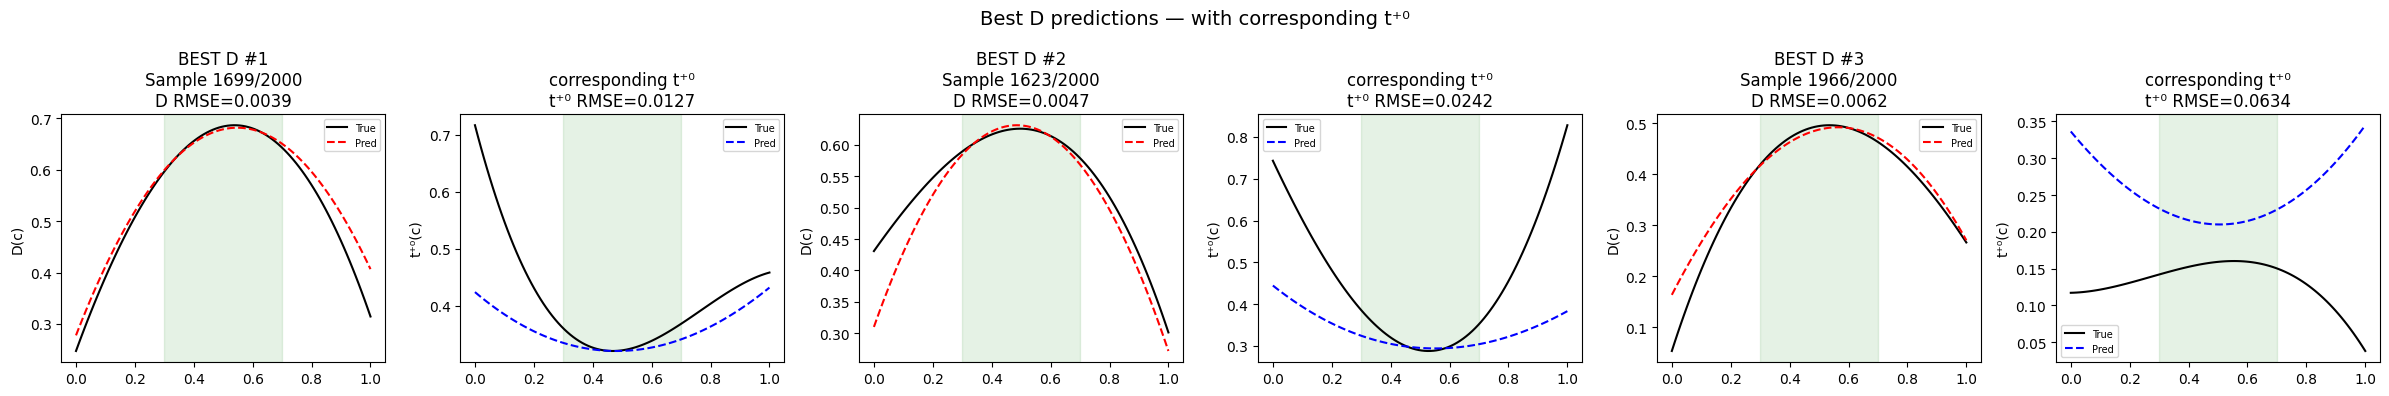

In [ ]:
# D best/worst — show corresponding t⁺⁰
D_best_idx = np.argsort(D_err_obs)[:3]


print("=== Best D samples — corresponding t⁺⁰ ===")
for i, idx in enumerate(D_best_idx):
    sid = test_dataset_ids[idx]
    print(f"  #{i+1} Sample {sid}/{N_samples} | D RMSE={D_err_obs[idx]:.4f} | t⁺⁰ RMSE={tp_err_obs[idx]:.4f}")
    print(f"    t⁺⁰ true: {y_test_phys[idx, 4:8].round(4)}")
    print(f"    t⁺⁰ pred: {y_pred_phys[idx, 4:8].round(4)}")

# Best D samples — show both D and t⁺⁰ side by side
D_best_idx = np.argsort(D_err_obs)[:3]



Moreover, good prediction of D does not imply good prediction of t+0. The predication of t+0 is systematically worse than The predication of D.

## 9. Real experiemnal data validation



Maps experimental data (181–15243s) onto the correct time window of the
COMSOL grid (0–28800s). Fills early times with uniform c and late times
with the last experimental profile.

CNN predictions:
  D:   [0.722, 0.785, 0.495, 0.010]

  t⁺⁰: [0.362, 0.494, 0.000, 0.4942]

![image-2.png](emily.png)

This model provides some level of predication of D value of the real system but can only guessed the mean of t+0.

## 10. Summary

**Input Channels:**
Two  channels (c, t) correlate strongly with D (|r| = 0.6–0.76) but weakly with t⁺⁰ (|r| = 0.06–0.41).
This confirms that c(x,t) under constant current carries much more D information than t⁺⁰ information.


**Feature engineering:** We add two physics-informed channels: ∂c/∂x (spatial gradient) and ∂c/∂t (temporal derivative), both derived from c(x,t). These appear directly in the governing PDE. ∂c/∂t also serves as a steadiness indicator — where it is near zero, the system is at steady state and ∂c/∂x encodes t⁺⁰ information; where it is large, D dominates.


**Performance of D**
The CNN predicts D(c) with R² = 0.76 for the interior Bernstein coefficients, which control the diffusivity in the experimentally observable concentration range. This demonstrates that the spatiotemporal concentration field c(x,t) carries sufficient information to recover the diffusivity function, consistent with D's strong influence on concentration evolution through the diffusion term in the governing PDE. Prediction accuracy degrades at the edges of the concentration range (R² ≈ 0.48 for boundary coefficients), reflecting the limited concentration coverage of the simulations — a limitation that could be addressed by varying the initial concentration.

**Performance of t+0**
The t⁺⁰ prediction achieves R² = 0.58 for interior coefficients with a variance ratio of 0.79, confirming the model captures real variation rather than defaulting to the mean. However, t⁺⁰ remains harder to predict than D (overall R² = 0.39 vs 0.62). Diagnostic analysis reveals two insights: first, t⁺⁰ accuracy is strongly coupled to D accuracy (Spearman r = 0.545), consistent with the D–t⁺⁰ coupling in the steady-state equation; second, samples with extreme t⁺⁰ values are harder to predict (r = 0.332), suggesting the model struggles at the edges of the parameter distribution. 
  

**Key insight:** this 2 phase,supervised, light physcis informed cnn model succesffully learned parterns from 4 input channel and 8 output targets with with mean regression R^2=0.76 for D and R^2=0.58 fpr t+0. onece recinstruct  to the physcial value, D shows great predication of the actual D value. however, the predication of t+0 is still poor. The fundamental limitation is in the input signal, not the model or regularization. Under constant current, the signal of t⁺⁰ is very subtle from c(x,t), even with the attention. It still performs much worse than D prediction.This is consistent with Mistry et al. (2025) needing two operando fields to identify both properties. Possible future improvement includes (1)expanding the observatble range of c(2)using input with various currents to decouple the D - t+0 correaltion. 

**Compare to PINN**
Faster training